# **KNN Classifier**

## **Project:**

* Diabetes Prediction System

## **Problem Statement:**

* Predict whether a patient has diabetes based on health parameters.  

In [1]:
# Step No 1 : Import Requird Libraries 

# Import numpy libarary 
import numpy as np 

# Import pandas libarary 
import pandas as pd 

# Import Plotting library 
import matplotlib.pyplot as plt 

# Import Advanced Plot library 
import seaborn as sns 

# Import train test split 
from sklearn.model_selection import train_test_split

# Import KNN Classifier
from sklearn.neighbors import KNeighborsClassifier

# Import Evaluation metrics 
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix 

In [2]:
# Step No 2 : Loading Dataset 
df = pd.read_csv("diabetes.csv")

In [3]:
# Step No 3 :  Understaning and Analysing Data 

# Display first rows 
print(df.head())

# Display statistical summary 
print(df.describe())

# Display dataset information 
print(df.info())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   

In [4]:
# Step No 4 : Data Cleaning 
# Check missing values 
print(df.isnull().sum())

# Check duplicate rows 
print(df.duplicated().sum())

# Remove duplicate rows 
df = df.drop_duplicates()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
0


In [5]:
# Step No 5 : Rename Target Column 
df = df.rename(columns={
    "Outcome":"Diabetes"
})

In [6]:
# Step No 6 : Features and Target Splitting
X = df[[
    "Pregnancies", 
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]]

# Define Target Variable
y = df["Diabetes"]

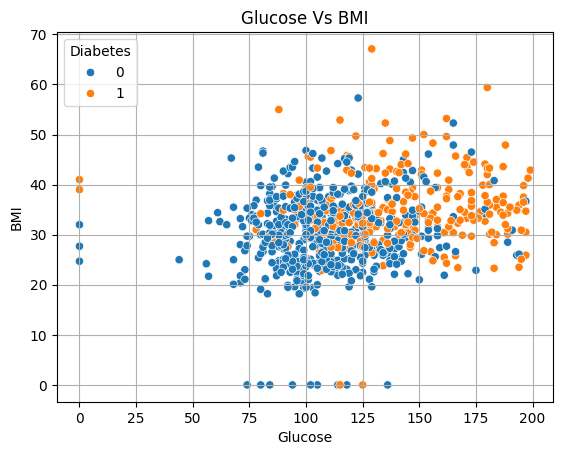

In [7]:
# Step NO 7 : Creating Glucose Vs BMI Plot (Visualization )

# Create scatter Plot 
sns.scatterplot(
    x = "Glucose",
    y = "BMI",
    hue = "Diabetes",
    data = df
)
# Set Plot title
plt.title("Glucose Vs BMI")

# Set x label
plt.xlabel("Glucose")

# Set y label 
plt.ylabel("BMI")

# Enable Grid 
plt.grid()

# Save figure 
plt.savefig("images/Glucose Vs BMI(KKN Classifier).png")

# Display Plot 
plt.show()

In [8]:
# Step No 8 : Split dataset 
X_train , X_test , y_train , y_test = train_test_split(
    X , 
    y , 
    test_size= 0.2,
    random_state= 42
)

In [9]:
# Step No 9 : Create scaler object 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 

In [10]:
# Step No 10 : Scale features 
X = scaler.fit_transform(X)

In [11]:
# Step No 11 : Create KNN Model 
model = KNeighborsClassifier(
    n_neighbors=5
)

In [12]:
# Step 12 : Train Model 
model.fit(X_train , y_train)

KNeighborsClassifier()

In [13]:
# Step No 13 : Predict output 
y_pred = model.predict(X_test)

# Display predictions 
print("Predicted Values : ")
print(y_pred)

Predicted Values : 
[0 0 0 1 0 1 0 0 1 1 0 1 0 0 0 1 0 0 1 0 1 0 1 0 1 1 0 0 0 0 1 0 1 1 0 0 1
 0 0 1 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 1 1 0 0 1 0 1 0
 1 0 1 1 0 1 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 1 1 1 0 1 1 0 0 0 0 1 0 0 0 0
 1 1 0 0 0 0]


In [14]:
# Step No 14 : Evaluation Metrics 

# Calculate Accuracy 
print("Accuracy Score : ")
print(accuracy_score(y_test , y_pred))

# Display Classification Report 
print("classification report : ")
print(classification_report(y_test , y_pred))

# Display Confusion Matrix 
print("Confusion Matrix : ")
print(confusion_matrix(y_test , y_pred))

Accuracy Score : 
0.6623376623376623
classification report : 
              precision    recall  f1-score   support

           0       0.75      0.71      0.73        99
           1       0.52      0.58      0.55        55

    accuracy                           0.66       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.66      0.67       154

Confusion Matrix : 
[[70 29]
 [23 32]]


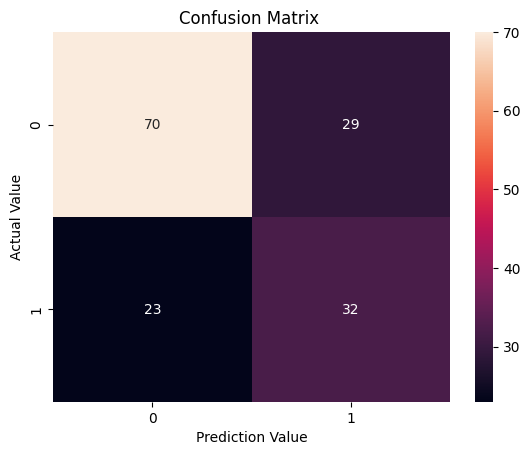

In [15]:
# Step No 15 : Plot Confusion Matrix Heatmap 
sns.heatmap(
    confusion_matrix(y_test , y_pred),
    annot=True,
    fmt="d"
)

# Set Plot title 
plt.title("Confusion Matrix ")

# Set X label 
plt.xlabel("Prediction Value")

# Set Y - label 
plt.ylabel("Actual Value")

# save figure 
plt.savefig("images/Confusion Matrix(KNN Classifier).png")

# Display Plot 
plt.show()

In [16]:
# Step No 16 : User Input 
# Take pregnancies input 
pregnancies = int(input("Enter Pregnancies : "))

# Take glucose input 
glucose = float(input("Enter Glucose : "))

# Take Blood Pressure input 
blood_pressure = float(input("Enter Blood Pressure : "))

# Take skin thickness input 
skin_thickness = float(input("Enter Skin Thickness : "))

# Take insulin input 
insulin = float(input("Enter Insulin : "))

# Take BMI input 
bmi = float(input("Enter BMI : "))

# Take diabetes pedigree input 
dpf = float(input("Enter Diabetes Pedigree Function : "))

# Take age input 
age = int(input("Enter Age : "))

In [17]:
# Step No 17 : Create User Dataframe 
user_data = pd.DataFrame({
    "Pregnancies": [pregnancies],
    "Glucose": [glucose],
    "BloodPressure": [blood_pressure],
    "SkinThickness": [skin_thickness],
    "Insulin": [insulin],
    "BMI": [bmi],
    "DiabetesPedigreeFunction": [dpf],
    "Age": [age]
})

In [18]:
# Step No 18 :  Scale user data 
user_data = scaler.transform(user_data)

In [19]:
# Step No 19 : Predict diabetes 
result = model.predict(user_data)

C:\Users\sagar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [20]:
# Step No 20 : Display final result 
if result[0] == 1 :
    print("Patient is Diabetic")
else:
    print("Patient is Not Diabetic")

Patient is Not Diabetic
